In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

trainset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)

classes = trainset.classes

print("Classes:")
print(classes)


Classes:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [3]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super(SimpleCNN, self).__init__()

        # First convolution layer
        self.conv1 = nn.Conv2d(
            3, 16, 3, padding=1
        )

        # Max pooling
        self.pool = nn.MaxPool2d(2, 2)

        # Second convolution layer
        self.conv2 = nn.Conv2d(
            16, 32, 3, padding=1
        )

        # Fully connected layers
        self.fc1 = nn.Linear(
            32 * 8 * 8,
            128
        )

        self.fc2 = nn.Linear(
            128,
            10
        )

        self.relu = nn.ReLU()

    def forward(self, x):

        # Conv1 -> ReLU -> Pool
        x = self.pool(
            self.relu(
                self.conv1(x)
            )
        )

        # Conv2 -> ReLU -> Pool
        x = self.pool(
            self.relu(
                self.conv2(x)
            )
        )

        # Flatten
        x = x.view(
            -1,
            32 * 8 * 8
        )

        # Fully connected layer
        x = self.relu(
            self.fc1(x)
        )

        # Output layer
        x = self.fc2(x)

        return x


In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("\nUsing device:", device)

model = SimpleCNN().to(device)

lossfn = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


Using device: cpu


In [5]:
epochs = 10

for epoch in range(epochs):

    running_loss = 0.0

    model.train()

    for inputs, labels in trainloader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Calculate loss
        loss = lossfn(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(trainloader)

    print(
        f"Epoch {epoch + 1}/{epochs}, "
        f"Loss: {avg_loss:.4f}"
    )


Epoch 1/10, Loss: 1.4656
Epoch 2/10, Loss: 1.1180
Epoch 3/10, Loss: 0.9639
Epoch 4/10, Loss: 0.8607
Epoch 5/10, Loss: 0.7817
Epoch 6/10, Loss: 0.7130
Epoch 7/10, Loss: 0.6564
Epoch 8/10, Loss: 0.5960
Epoch 9/10, Loss: 0.5428
Epoch 10/10, Loss: 0.4940


In [6]:

correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in testloader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


accuracy = 100 * correct / total

print(
    f"\nAccuracy on test data: "
    f"{accuracy:.2f}%"
)



Accuracy on test data: 69.46%


In [7]:
def visualize_filters(layer, n_filters=8):

    filters = (
        layer.weight.data.clone().cpu()
    )

    fig, axs = plt.subplots(
        1,
        n_filters,
        figsize=(15, 4)
    )

    for i in range(n_filters):

        f = filters[i]

        # Normalize filter values
        f = (
            f - f.min()
        ) / (
            f.max() - f.min()
        )

        axs[i].imshow(
            f.permute(1, 2, 0)
        )

        axs[i].axis("off")

        axs[i].set_title(
            f"Filter {i + 1}"
        )

    plt.tight_layout()
    plt.show()

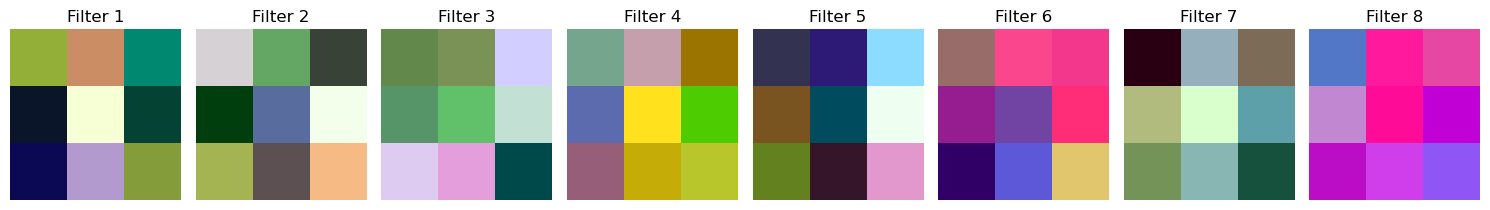

In [8]:
visualize_filters(
    model.conv1,
    n_filters=8
)